# Particles and Beds

`difflow.particles` holds pure JAX functions for flow past particles and through particle beds:
drag and terminal velocity, the full Ergun pressure drop, minimum fluidization and bed expansion.
They are building blocks (not unit operations) for adsorbers, catalytic beds, settlers and filters.
Correlations: Haider & Levenspiel (1989), Turton & Levenspiel (1986), Ergun (1952), Wen & Yu (1966),
Richardson & Zaki (1954). See *Particles and Beds* in `docs/unit-operations-chemical.md` for what is
verified and what is not.

## 1. Drag curve and terminal velocity

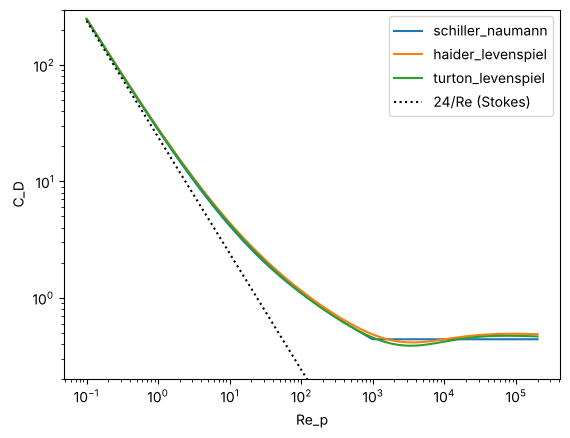

In [1]:
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from difflow.particles import *

Re = np.logspace(-1, np.log10(2e5), 200)
for m in DRAG_METHODS:
    plt.loglog(Re, [float(drag_coefficient(r, 1.0, m)) for r in Re], label=m)
plt.loglog(Re, 24 / Re, 'k:', label='24/Re (Stokes)')
plt.xlabel('Re_p'); plt.ylabel('C_D'); plt.ylim(0.2, 300); plt.legend(); plt.show()

In [2]:
# Terminal velocity of quartz-density spheres in water, Stokes -> Newton regime,
# and its exact derivative through the implicit root find.
for d in [10e-6, 100e-6, 1e-3, 1e-2]:
    v = terminal_velocity(d, 2650.0, 998.0, 1e-3)
    dv = jax.grad(terminal_velocity)(d, 2650.0, 998.0, 1e-3)
    print(f"d = {d*1e6:8.0f} um   v_t = {float(v):.5f} m/s   dv/dd = {float(dv):10.2f} 1/s")

d =       10 um   v_t = 0.00009 m/s   dv/dd =      17.93 1/s
d =      100 um   v_t = 0.00777 m/s   dv/dd =     136.42 1/s
d =     1000 um   v_t = 0.15070 m/s   dv/dd =     139.85 1/s
d =    10000 um   v_t = 0.71229 m/s   dv/dd =      31.46 1/s


## 2. Packed-bed pressure drop (Ergun)

In [3]:
dpdl, info = ergun_pressure_gradient(1.0, 3e-3, 0.4, 1.2, 1.8e-5)   # 3 mm spheres in air
print("dP/L =", float(dpdl), "Pa/m  (hand calculation: 1687.5 viscous + 6562.5 inertial = 8250)")
print({k: float(v) for k, v in info.items()})
g = jax.grad(lambda d, e: ergun_pressure_gradient(1.0, d, e, 1.2, 1.8e-5)[0], argnums=(0, 1))(3e-3, 0.4)
print("d(dP/L)/d(d_p), d(dP/L)/d(eps) =", [float(x) for x in g])

dP/L = 8249.999999999998 Pa/m  (hand calculation: 1687.5 viscous + 6562.5 inertial = 8250)
{'viscous': 1687.4999999999995, 'inertial': 6562.499999999999, 'Re_bed': 333.3333333333333}


d(dP/L)/d(d_p), d(dP/L)/d(eps) = [-3312499.999999999, -78437.49999999997]


## 3. Fluidization window and bed expansion

In [4]:
u_mf, u_t = fluidization_window(300e-6, 2600.0, 1.2, 1.8e-5, 0.45, 0.8)
print(f"u_mf = {float(u_mf):.4f} m/s (Ergun), Wen-Yu: "
      f"{float(minimum_fluidization_velocity(300e-6, 2600.0, 1.2, 1.8e-5, method='wen_yu')):.4f} m/s, u_t = {float(u_t):.2f} m/s")
print("Geldart group:", geldart_group(300e-6, 2600.0, 1.2), "(not differentiable)")

# Richardson-Zaki expansion of a liquid-fluidized bed: 500 um glass beads in water
d, rp, rf, mu = 500e-6, 2500.0, 998.0, 1e-3
u_t = terminal_velocity(d, rp, rf, mu)
Re_t = terminal_reynolds(d, rp, rf, mu)
print(f"liquid bed: u_t = {float(u_t):.3f} m/s, Re_t = {float(Re_t):.0f}, n = {float(richardson_zaki_exponent(Re_t)):.2f}")
u = jnp.linspace(0.2, 0.8, 4) * u_t
eps, H = bed_expansion(u, u_t, Re_t=Re_t, voidage_mf=0.45, H_mf=1.0)
for ui, e, h in zip(u, eps, H):
    print(f"u = {float(ui):.3f} m/s  voidage = {float(e):.3f}  H/H_mf = {float(h):.3f}")


u_mf = 0.0875 m/s (Ergun), Wen-Yu: 0.0754 m/s, u_t = 2.12 m/s
Geldart group: B (not differentiable)


liquid bed: u_t = 0.070 m/s, Re_t = 35, n = 3.12


u = 0.014 m/s  voidage = 0.597  H/H_mf = 1.364
u = 0.028 m/s  voidage = 0.745  H/H_mf = 2.160
u = 0.042 m/s  voidage = 0.849  H/H_mf = 3.639
u = 0.056 m/s  voidage = 0.931  H/H_mf = 7.962


## 4. `GasPFR` with a physical bed

Instead of a lumped `alpha`, give the bed and let Ergun compute it.

In [5]:
from difflow import make_stream
from difflow.units.pfr import GasPFR, GasPFRParams

bed = dict(d_p=3e-3, voidage=0.4, mu=1.8e-5, rho_gas=1.2, u_s0=1.0, bed_area=0.5)
def make(**kw):
    return GasPFRParams(V=1.0, rate_fn=lambda C, T, p: jnp.zeros(1), stoich=jnp.array([[-1.0], [1.0]]),
                        rate_params={}, species_order=['A', 'B'], **kw)
inlet = make_stream({'A': 1.0, 'B': 0.0}, 400.0, 2.0e5)
_, ia = GasPFR(make(alpha=16500.0))(inlet)
_, ib = GasPFR(make(**bed))(inlet)
print("alpha from Ergun:", float(make(**bed).effective_alpha), "Pa/m^3")
print("pressure drop, explicit alpha vs physical bed:", float(ia['pressure_drop']), float(ib['pressure_drop']))

alpha from Ergun: 16499.999999999996 Pa/m^3
pressure drop, explicit alpha vs physical bed: 17243.331159257155 17243.331159257155
